Pré-traitement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import os

print("✅ Libraries importées avec succès")

✅ Libraries importées avec succès


In [2]:
df = pd.read_csv('../data/Loan_Data.csv')
print(f"Shape original : {df.shape}")
df.head()

Shape original : (10000, 8)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [3]:
# customer_id n'est pas une feature prédictive
df = df.drop(columns=['customer_id'])
print(f"Shape après suppression customer_id : {df.shape}")
print(df.columns.tolist())

Shape après suppression customer_id : (10000, 7)
['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']


In [4]:
print(f"Doublons : {df.duplicated().sum()}")
print(f"Valeurs manquantes :\n{df.isnull().sum()}")

# Supprimer les doublons si existants
df = df.drop_duplicates()
print(f"\nShape après nettoyage : {df.shape}")

Doublons : 0
Valeurs manquantes :
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

Shape après nettoyage : (10000, 7)


In [5]:
# Créer de nouvelles features pertinentes
df['debt_to_income'] = df['total_debt_outstanding'] / df['income']
df['loan_to_income'] = df['loan_amt_outstanding'] / df['income']

print("✅ Nouvelles features créées :")
print("- debt_to_income : ratio dette totale / revenu")
print("- loan_to_income : ratio prêt / revenu")
df.head()

✅ Nouvelles features créées :
- debt_to_income : ratio dette totale / revenu
- loan_to_income : ratio prêt / revenu


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,debt_to_income,loan_to_income
0,0,5221.545193,3915.471226,78039.38546,5,605,0,0.050173,0.066909
1,5,1958.928726,8228.752520,26648.43525,2,572,1,0.308789,0.073510
2,0,3363.009259,2027.830850,65866.71246,4,602,0,0.030787,0.051058
3,0,4766.648001,2501.730397,74356.88347,5,612,0,0.033645,0.064105
4,1,1345.827718,1768.826187,23448.32631,6,631,0,0.075435,0.057395


In [6]:
X = df.drop(columns=['default'])
y = df['default']

print(f"Features (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nFeatures utilisées : {X.columns.tolist()}")
print(f"\nDistribution target :\n{y.value_counts()}")
print(f"Taux de défaut : {y.mean()*100:.2f}%")

Features (X) : (10000, 8)
Target (y)   : (10000,)

Features utilisées : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'debt_to_income', 'loan_to_income']

Distribution target :
default
0    8149
1    1851
Name: count, dtype: int64
Taux de défaut : 18.51%


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Important pour garder le même ratio défaut/non-défaut
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nDistribution train :\n{y_train.value_counts()}")
print(f"\nDistribution test :\n{y_test.value_counts()}")

X_train : (8000, 8)
X_test  : (2000, 8)

Distribution train :
default
0    6519
1    1481
Name: count, dtype: int64

Distribution test :
default
0    1630
1     370
Name: count, dtype: int64


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ Normalisation effectuée")
print(f"\nMoyenne avant scaling : {X_train.mean().round(2)}")
print(f"\nMoyenne après scaling : {X_train_scaled.mean().round(2)}")

✅ Normalisation effectuée

Moyenne avant scaling : credit_lines_outstanding        1.46
loan_amt_outstanding         4152.93
total_debt_outstanding       8687.01
income                      69945.12
years_employed                  4.55
fico_score                    637.39
debt_to_income                  0.12
loan_to_income                  0.06
dtype: float64

Moyenne après scaling : credit_lines_outstanding    0.0
loan_amt_outstanding       -0.0
total_debt_outstanding     -0.0
income                     -0.0
years_employed              0.0
fico_score                  0.0
debt_to_income              0.0
loan_to_income             -0.0
dtype: float64


Avant SMOTE : {0: 6519, 1: 1481}
Après SMOTE : {1: 6519, 0: 6519}

Nouvel équilibre : 50.00% de défauts


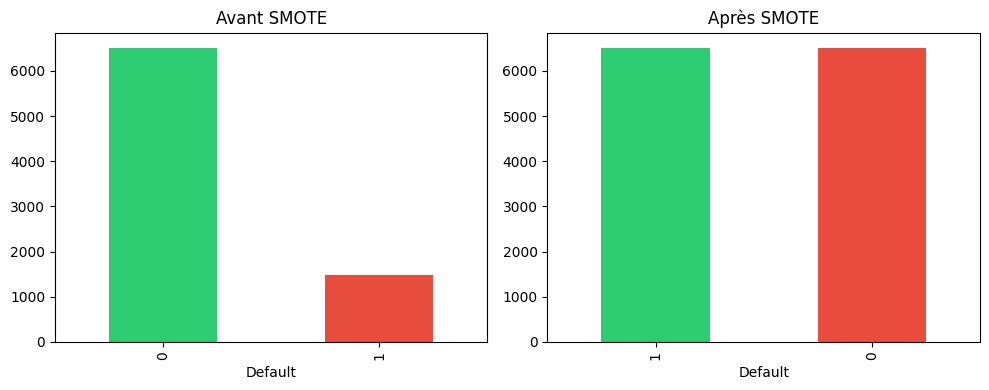

In [9]:
print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Après SMOTE : {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"\nNouvel équilibre : {pd.Series(y_train_resampled).mean()*100:.2f}% de défauts")

# Visualiser
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Avant SMOTE')
ax1.set_xlabel('Default')

pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'])
ax2.set_title('Après SMOTE')
ax2.set_xlabel('Default')

plt.tight_layout()
plt.savefig('../data/smote_balance.png')
plt.show()

In [10]:
# Créer le dossier processed
os.makedirs('../data/processed', exist_ok=True)

# Sauvegarder les datasets
X_train_resampled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)
pd.Series(y_train_resampled).to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Sauvegarder le scaler pour le déploiement
joblib.dump(scaler, '../data/processed/scaler.pkl')

print("✅ Données sauvegardées dans data/processed/")
print("✅ Scaler sauvegardé : data/processed/scaler.pkl")

✅ Données sauvegardées dans data/processed/
✅ Scaler sauvegardé : data/processed/scaler.pkl


In [11]:
print("=" * 50)
print("📊 RÉSUMÉ DU PRÉ-TRAITEMENT")
print("=" * 50)
print(f"Features finales     : {X_train_resampled.shape[1]}")
print(f"X_train (après SMOTE): {X_train_resampled.shape}")
print(f"X_test               : {X_test_scaled.shape}")
print(f"Scaler               : StandardScaler sauvegardé ✅")
print("=" * 50)

📊 RÉSUMÉ DU PRÉ-TRAITEMENT
Features finales     : 8
X_train (après SMOTE): (13038, 8)
X_test               : (2000, 8)
Scaler               : StandardScaler sauvegardé ✅
